# Reporte Analítico Profesional: Minería de Reglas de Asociación y Análisis de Afinidad (Market Basket Analysis)

**Curso:** Minería de Datos   
**Proyecto:** SmartBazar – Pipeline de Machine Learning para Retail  
**Insumo de Entrada:** Datasets Saneados (`datasets/limpio/` – Salida del Cuaderno 1A)  
**Enfoque:** Reporte de Inteligencia de Negocio y Estrategias de Cross-Selling  

---

## Resumen Ejecutivo

El presente reporte analítico ejecuta un estudio transaccional exhaustivo (*Market Basket Analysis*) sobre el comportamiento de compra en tienda. A diferencia de un análisis exploratorio simple, este reporte compara modelos algorítmicos (**Apriori vs FP-Growth**) en múltiples niveles de granularidad (**SKU Específico, Categoría Universal y Departamento**) para descubrir patrones de compra cruzada, sinergias ocultas y oportunidades estratégicas de distribución física y promocional.

### Guía de Métricas para la Toma de Decisiones de Negocio:
* **Soporte ($Support$):** Mide la **frecuencia de mercado** o alcance de un producto/combo. Un soporte del $2\%$ indica que 2 de cada 100 clientes adquieren esa combinación en un mismo ticket.
* **Confianza ($Confidence$):** Mide la **tasa de conversión condicional**. Si $conf(X \rightarrow Y) = 60\%$, significa que el 60% de los clientes que colocaron el producto $X$ en su canasta también compraron el producto $Y$.
* **Elevación ($Lift$):** Es el indicador clave de **verdadera sinergia o dependencia**. 
  * $Lift = 1.0$: Compras independientes (azar).
  * $Lift > 1.0$: **Atracción y afinidad positiva** (ej. $Lift = 3.5$ significa que comprar $X$ multiplica por 3.5 las probabilidades de comprar $Y$).
  * $Lift < 1.0$: Sustitución o repulsión entre productos.
* **Convicción ($Conviction$):** Evalúa qué tanto dependería el quiebre del consecuente si se deja de vender el antecedente.

## Bloque 1: Setup, Carga de Datos y Preparación Transaccional

En este primer bloque cargamos el motor analítico, exploramos las características transaccionales básicas (distribución de tamaño de ticket) y transformamos las tablas relacionales en matrices binarias (*One-Hot Encoding*) optimizadas para la minería de patrones.

In [39]:
# 1.1 Configuración e Importaciones de Librerías Analíticas
try:
    import mlxtend
except ImportError:
    !pip install mlxtend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
import time
import os
import warnings

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore')

# Configuraciones de estilo y presentación visual profesional
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
np.random.seed(42)

✔️ Volumen de transacciones (Tickets únicos): 939
✔️ Volumen de ítems vendidos (Líneas de detalle): 1,240



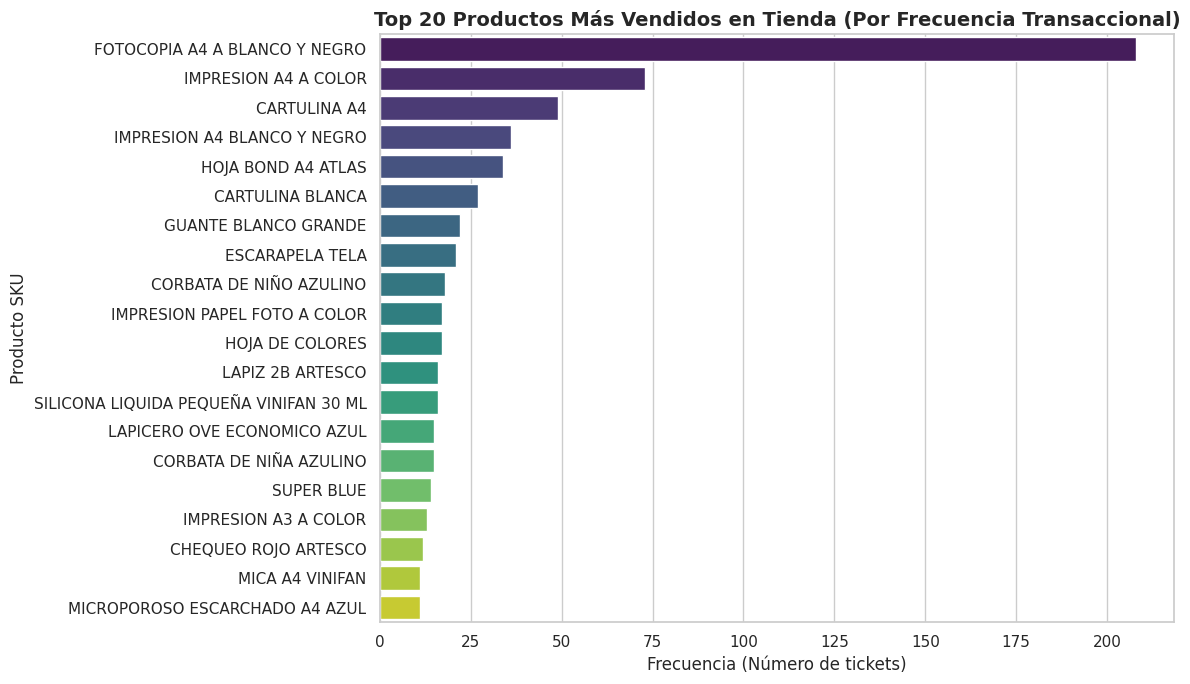

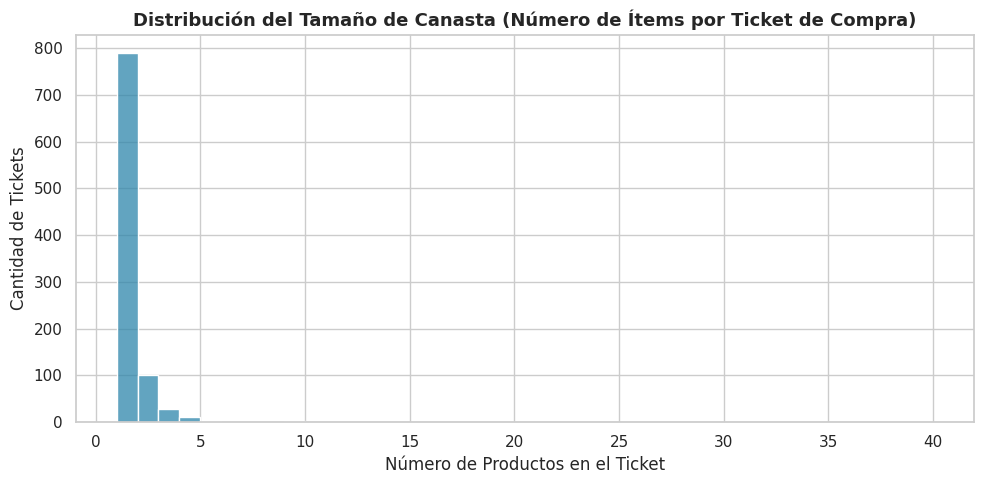

📊 Estadísticas de Tamaño de Ticket (Productos distintos por transacción):


,count,mean,std,min,25%,50%,75%,max
ID_Producto,939.000000,1.317359,1.617939,0.000000,1.000000,1.000000,1.000000,39.000000


In [40]:
# 1.2 Carga de Datos y Exploración Transaccional Inicial
DIR_LIMPIO = 'datasets/limpio/'
df_ventas = pd.read_csv(os.path.join(DIR_LIMPIO, 'ventas.csv'))
df_detalle = pd.read_csv(os.path.join(DIR_LIMPIO, 'detalle_ventas.csv'))

print(f"✔️ Volumen de transacciones (Tickets únicos): {df_ventas.shape[0]:,}")
print(f"✔️ Volumen de ítems vendidos (Líneas de detalle): {df_detalle.shape[0]:,}\n")

# Top 20 productos más frecuentes en tienda
prod_frecuentes = df_detalle['Descripcion'].value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=prod_frecuentes.values, y=prod_frecuentes.index, palette="viridis")
plt.title('Top 20 Productos Más Vendidos en Tienda (Por Frecuencia Transaccional)', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia (Número de tickets)')
plt.ylabel('Producto SKU')
plt.tight_layout()
plt.show()

# Distribución de la cantidad de ítems por ticket
prod_por_ticket = df_detalle.groupby('ID_Venta')['ID_Producto'].count()

plt.figure(figsize=(10, 5))
sns.histplot(prod_por_ticket, bins=range(1, prod_por_ticket.max() + 2), kde=False, color="#2E86AB")
plt.title('Distribución del Tamaño de Canasta (Número de Ítems por Ticket de Compra)', fontsize=13, fontweight='bold')
plt.xlabel('Número de Productos en el Ticket')
plt.ylabel('Cantidad de Tickets')
plt.tight_layout()
plt.show()

productos_distintos = df_detalle.groupby('ID_Venta')['ID_Producto'].nunique()
print("📊 Estadísticas de Tamaño de Ticket (Productos distintos por transacción):")
display(pd.DataFrame(productos_distintos.describe()).T.style.background_gradient(cmap='Blues'))

### 1.3 Construcción del Diccionario de Categorización Universal (Clean Code)

Para superar la dispersión estadística (*sparsity*) natural del retail —donde las ventas de un producto como la silicona líquida se dividen entre 10 marcas, tallas y volúmenes diferentes—, aplicamos un proceso de **generalización conceptual pura**.

> [!IMPORTANT]
> **Buenas Prácticas de Ingeniería de Datos (Clean Code):**  
> Se elimina por completo el anti-patrón de múltiples declaraciones condicionales `if/elif`. En su lugar, se diseña un **diccionario de mapeo declarativo (`diccionario_mapeo`)** y una función iterativa limpia.  
> **Nota de Producción:** En un entorno productivo real, este diccionario y su lógica de categorización deben aislarse en un módulo independiente (`utils.py`) e importarse dinámicamente (`from utils import categorizar_producto`) para garantizar mantenibilidad, testabilidad y separación de responsabilidades.

In [41]:
diccionario_mapeo = {
    # Escritura y Trazado
    "LAPIZ 2B": "LAPIZ",
    "PORTAMINAS": "LAPIZ",
    "LÁPIZ": "LAPIZ",
    "LAPIZ": "LAPIZ",
    "CARBONCILLO": "LAPIZ",
    "FRIXION": "LAPICERO",
    "LAPICERO": "LAPICERO",
    "PLUMON": "PLUMON / RESALTADOR",
    "PLUMÓN": "PLUMON / RESALTADOR",
    "RESALTADOR": "PLUMON / RESALTADOR",
    "CHEQUEO": "PLUMON / RESALTADOR",
    "MARKER": "PLUMON / RESALTADOR",
    "INDELEBLE": "PLUMON / RESALTADOR",
    "CORRECTOR": "CORRECTOR",
    "MINAS": "MINAS / REPUESTOS",
    "TIZA": "TIZA",
    
    # Arte, Dibujo y Manualidades
    "LAPICES DE COLOR": "COLORES",
    "COLORES": "COLORES",
    "CRAYON": "CRAYOLAS",
    "CRAYOLA": "CRAYOLAS",
    "TEMPERA": "TEMPERA",
    "TÉMPERA": "TEMPERA",
    "PINCEL": "PINCEL",
    "PALETA": "ACCESORIOS DE PINTURA",
    "PLASTILINA": "PLASTILINA",
    "LENTEJUELA": "LENTEJUELAS Y ESCARCHA",
    "ESCARCHA": "LENTEJUELAS Y ESCARCHA",
    "OROPEL": "PAPEL OROPEL",
    "MICROPOROSO": "MICROPOROSO",
    "PALITOS DE CHUPETE": "PALITOS DE MANUALIDADES",
    "BAJA LENGUA": "PALITOS DE MANUALIDADES",
    "OJOS MOVILES": "MANUALIDADES",
    "PUNZON": "HERRAMIENTAS DE MANUALIDADES",
    "ESPONJA": "ESPONJA",
    "ALGODÓN": "ALGODON",
    "ALGODON": "ALGODON",
    
    # Pegamentos y Adhesivos
    "SILICONA": "SILICONA",
    "GOMA": "GOMA",
    "CINTA MASKING": "CINTA ADHESIVA / EMBALAJE",
    "CINTA EMBALAJE": "CINTA ADHESIVA / EMBALAJE",
    "CINTA DE ESCRITORIO": "CINTA ADHESIVA / EMBALAJE",
    "CINTA DE AGUA": "CINTAS DECORATIVAS Y AGUA",
    "LIMPIATIPO": "LIMPIATIPOS",
    
    # Cuadernos, Blocks y Papelería
    "SKETCH BOOK": "BLOCK / SKETCH BOOK",
    "BLOCK": "BLOCK / SKETCH BOOK",
    "CUADERNO": "CUADERNO",
    "POST-IT": "NOTAS ADHESIVAS / POST-IT",
    "HOJA BOND": "HOJA BOND",
    "PAPEL BOND": "HOJA BOND",
    "HOJA DE COLOR": "HOJAS DE COLORES",
    "HOJAS DE COLOR": "HOJAS DE COLORES",
    "CARTUILINA": "CARTULINA",
    "CARTULINA": "CARTULINA",
    "PAPEL CREPE": "PAPEL CREPE",
    "PAPEL LUSTRE": "PAPEL LUSTRE",
    "PAPEL KRAFT": "PAPEL ESPECIAL / KRAFT",
    "PAPEL CRAFT": "PAPEL ESPECIAL / KRAFT",
    "PAPEL DE SEDA": "PAPEL DE SEDA",
    "PAPEL DE SEDE": "PAPEL DE SEDA",
    "PAPEL MANTECA": "PAPEL ESPECIAL",
    "PAPEL DE REGALO": "PAPEL DE REGALO",
    "PAPELOTE": "PAPELOTE",
    "SOBRE": "SOBRE",
    "TARJETA BIBLIOGRAFICA": "TARJETA BIBLIOGRAFICA",
    "BILLETE Y MONEDA": "MATERIAL DIDACTICO",
    "TABLA PERIODICA": "MATERIAL DIDACTICO",
    "LAMINAS": "LAMINAS DIDACTICAS",
    
    # Organización, Archivo y Sujetadores
    "FOLDER": "FOLDER",
    "MICA": "MICA / FOTOCHECK",
    "PLASTIFORRO": "FORRO / VINIFAN",
    "VINIFAN": "FORRO / VINIFAN",
    "FASTER": "SUJETADORES / FASTERS",
    "CHINCHE": "SUJETADORES / CHINCHES",
    "GRAPA": "SUJETADORES / GRAPAS",
    "LIGAS": "SUJETADORES / LIGAS",
    "PABILO": "PABILO",
    
    # Herramientas y Accesorios de Escritorio
    "TIJERA": "TIJERA / CUTER",
    "CUTER": "TIJERA / CUTER",
    "TAJADOR": "TAJADOR",
    "BORRADOR": "BORRADOR",
    "REGLA": "REGLA / GEOMETRIA",
    "ESCUADRA": "REGLA / GEOMETRIA",
    "TRANSPORTADOR": "REGLA / GEOMETRIA",
    "PERFORADOR": "PERFORADOR",
    "CALCULADORA": "CALCULADORA",
    "MOTA": "MOTA",
    "TAMPON": "TAMPON Y TINTAS",
    "TINTA": "TAMPON Y TINTAS",
    "LUPA": "LUPA",
    "PERCHERO": "PERCHERO",
    
    # Artículos Festivos y Recreación
    "GLOBO": "GLOBOS Y ACCESORIOS",
    "PALIGLOBO": "GLOBOS Y ACCESORIOS",
    "SERPENTINA": "SERPENTINA Y PICA PICA",
    "PICA PICA": "SERPENTINA Y PICA PICA",
    "FLAUTA": "INSTRUMENTOS MUSICALES",
    "PITO": "ARTICULOS DEPORTIVOS Y RECREACION",
    
    # Artículos Cívicos y Uniforme
    "CORBATA": "ARTICULOS CIVICOS Y UNIFORME",
    "ESCARAPELA": "ARTICULOS CIVICOS Y UNIFORME",
    "BANDERA": "ARTICULOS CIVICOS Y UNIFORME",
    "INSIGNA": "ARTICULOS CIVICOS Y UNIFORME",
    "PALO DE BRIGADIER": "ARTICULOS CIVICOS Y UNIFORME",
    "CORREA": "ARTICULOS CIVICOS Y UNIFORME",
    "GUANTE": "GUANTES E HIGIENE",
    "MANDIL": "MANDIL Y BOLSA",
    "BOLSA": "MANDIL Y BOLSA",
    
    # Servicios y Otros
    "FOTOCOPIA": "FOTOCOPIA E IMPRESION",
    "IMPRESION": "FOTOCOPIA E IMPRESION",
    "TIPEO": "SERVICIOS",
    "SUPER BLUE": "ACCESORIOS DE LIMPIEZA",
    "PRODUCTO": "GENERAL / OTROS"
}

def categorizar_producto(descripcion, diccionario=diccionario_mapeo):
    if not isinstance(descripcion, str):
        return "OTRO"
    desc_upper = descripcion.upper().strip()
    for clave, categoria in diccionario.items():
        if clave in desc_upper:
            return categoria
    return "OTRO"

# Aplicación limpia del mapeo
df_detalle['Producto_Universal'] = df_detalle['Descripcion'].apply(categorizar_producto)
print("✔️ Categorización universal aplicada con éxito mediante diccionario modular.")

✔️ Categorización universal aplicada con éxito mediante diccionario modular.


### 1.4 Generación de Matrices One-Hot Encoding (Multi-Granularidad)

Construimos las tres matrices binarias de transacciones para evaluar el impacto de la generalización en la densidad estadística:
1. **Matriz SKU Detallado:** Alta especificidad, mayor dispersión (*sparsity*).
2. **Matriz Categoría Universal:** Consolidación conceptual por familia de producto, alta concentración de soporte.
3. **Matriz Departamento:** Afinidad macro por secciones físicas de tienda.

In [42]:
# 1. NIVEL PRODUCTO DETALLADO (SKU ESPECÍFICO)
transacciones_prod = df_detalle.groupby('ID_Venta')['Descripcion'].apply(list).tolist()
te = TransactionEncoder()
te_ary = te.fit(transacciones_prod).transform(transacciones_prod)
df_trans_prod = pd.DataFrame(te_ary, columns=te.columns_)

sparsidad_prod = 1.0 - (df_trans_prod.values.sum() / df_trans_prod.size)

# Filtrado de ítems ultra-raros (>1% soporte) para concentrar señal en SKU detallado
min_apariciones = int(df_trans_prod.shape[0] * 0.01)
df_trans_prod = df_trans_prod.loc[:, df_trans_prod.sum() >= min_apariciones]

# 2. NIVEL PRODUCTO UNIVERSAL (GENÉRICO / GENERAL)
transacciones_univ = df_detalle.groupby('ID_Venta')['Producto_Universal'].apply(lambda x: list(set(x))).tolist()
te_univ = TransactionEncoder()
te_univ_ary = te_univ.fit(transacciones_univ).transform(transacciones_univ)
df_trans_univ = pd.DataFrame(te_univ_ary, columns=te_univ.columns_)

sparsidad_univ = 1.0 - (df_trans_univ.values.sum() / df_trans_univ.size)

# 3. NIVEL DEPARTAMENTO
transacciones_dept = df_detalle.groupby('ID_Venta')['Departamento'].apply(lambda x: list(set(x))).tolist()
te_dept = TransactionEncoder()
te_dept_ary = te_dept.fit(transacciones_dept).transform(transacciones_dept)
df_trans_dept = pd.DataFrame(te_dept_ary, columns=te_dept.columns_)

sparsidad_dept = 1.0 - (df_trans_dept.values.sum() / df_trans_dept.size)

# Tabla resumen de matrices transaccionales
resumen_matrices = pd.DataFrame({
    'Granularidad / Nivel': ['SKU Detallado (Filtrado >1%)', 'Categoría Universal (Genérico)', 'Departamento Macro'],
    'Transacciones (Filas)': [df_trans_prod.shape[0], df_trans_univ.shape[0], df_trans_dept.shape[0]],
    'Ítems Únicos (Columnas)': [df_trans_prod.shape[1], df_trans_univ.shape[1], df_trans_dept.shape[1]],
    'Dispersión / Sparsidad (%)': [f"{sparsidad_prod:.2%}", f"{sparsidad_univ:.2%}", f"{sparsidad_dept:.2%}"]
})

print("📋 Resumen Estructural de Matrices Transaccionales Generadas:")
display(resumen_matrices.style.set_properties(**{'font-weight': 'bold', 'background-color': '#f8f9fa'}).background_gradient(subset=['Ítems Únicos (Columnas)'], cmap='Purples'))

print("\n🔍 Muestra preliminar de la Matriz Transaccional Universal (Primeros 5 registros):")
display(df_trans_univ.head(5).style.background_gradient(cmap='Greens'))

📋 Resumen Estructural de Matrices Transaccionales Generadas:


,Granularidad / Nivel,Transacciones (Filas),Ítems Únicos (Columnas),Dispersión / Sparsidad (%)
0,SKU Detallado (Filtrado >1%),939,26,99.47%
1,Categoría Universal (Genérico),939,64,98.16%
2,Departamento Macro,939,2,49.63%



🔍 Muestra preliminar de la Matriz Transaccional Universal (Primeros 5 registros):


,ACCESORIOS DE LIMPIEZA,ACCESORIOS DE PINTURA,ALGODON,ARTICULOS CIVICOS Y UNIFORME,ARTICULOS DEPORTIVOS Y RECREACION,BLOCK / SKETCH BOOK,BORRADOR,CARTULINA,CINTA ADHESIVA / EMBALAJE,CINTAS DECORATIVAS Y AGUA,COLORES,CORRECTOR,CRAYOLAS,CUADERNO,ESPONJA,FOLDER,FORRO / VINIFAN,FOTOCOPIA E IMPRESION,GENERAL / OTROS,GLOBOS Y ACCESORIOS,GOMA,GUANTES E HIGIENE,HOJA BOND,HOJAS DE COLORES,INSTRUMENTOS MUSICALES,LAPICERO,LAPIZ,LENTEJUELAS Y ESCARCHA,LIMPIATIPOS,LUPA,MANDIL Y BOLSA,MANUALIDADES,MATERIAL DIDACTICO,MICA / FOTOCHECK,MICROPOROSO,MINAS / REPUESTOS,MOTA,NOTAS ADHESIVAS / POST-IT,OTRO,PABILO,PALITOS DE MANUALIDADES,PAPEL CREPE,PAPEL DE SEDA,PAPEL ESPECIAL,PAPEL ESPECIAL / KRAFT,PAPEL LUSTRE,PAPELOTE,PERFORADOR,PINCEL,PLASTILINA,PLUMON / RESALTADOR,REGLA / GEOMETRIA,SERPENTINA Y PICA PICA,SERVICIOS,SILICONA,SOBRE,SUJETADORES / CHINCHES,SUJETADORES / FASTERS,SUJETADORES / GRAPAS,SUJETADORES / LIGAS,TAMPON Y TINTAS,TARJETA BIBLIOGRAFICA,TEMPERA,TIJERA / CUTER
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Bloque 2: Modelado Multi-Algoritmo (Apriori vs FP-Growth)

Ejecutamos la minería de itemsets frecuentes y generación de reglas bajo ambos motores algorítmicos:
* **Apriori:** Búsqueda exhaustiva nivel a nivel combinando candidatos.
* **FP-Growth:** Compresión transaccional en árboles de patrones frecuentes (*FP-Tree*), superando los cuellos de botella de rendimiento en alta dispersión.

### 2.1 Modelado a Nivel Producto Detallado (SKU Específico)

Iniciamos con un análisis de sensibilidad para determinar el soporte mínimo óptimo, equilibrando la retención de asociaciones valiosas sin saturar el ruido estadístico de SKUs de baja rotación.

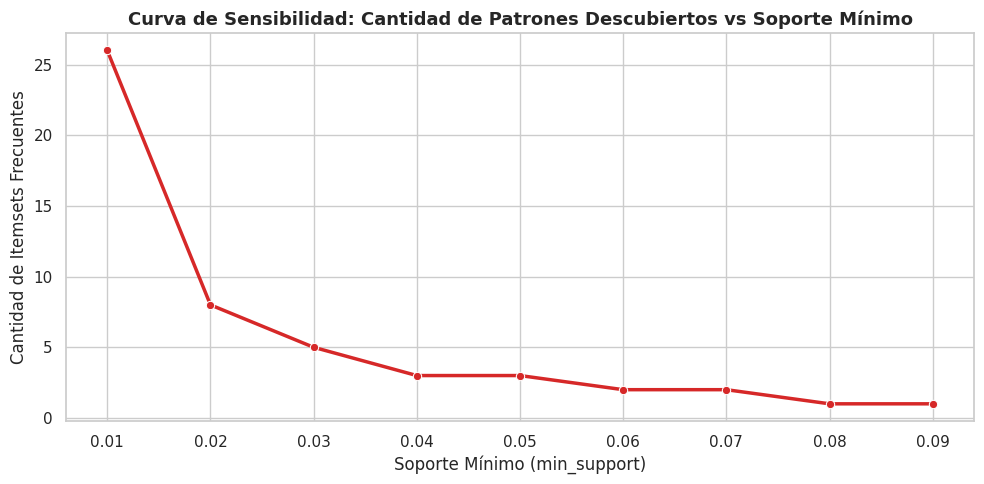

⏱️ Tiempo Apriori (SKU Detallado): 0.0064s | Itemsets: 33 | Reglas (Lift>1): 14
⏱️ Tiempo FP-Growth (SKU Detallado): 0.0333s | Itemsets: 33 | Reglas (Lift>1): 14

🏆 Top 10 Reglas SKU Detallado (Ordenadas por Elevación / Lift):


,rule_name,support,confidence,lift
7,CHEQUEO ROJO ARTESCO -> LAPIZ 2B ARTESCO,0.75%,58.33%,34.23
6,LAPIZ 2B ARTESCO -> CHEQUEO ROJO ARTESCO,0.75%,43.75%,34.23
13,SILICONA LIQUIDA PEQUEÑA VINIFAN 30 ML -> MICROPOROSO ESCARCHADO A4 AZUL,0.53%,31.25%,26.68
12,MICROPOROSO ESCARCHADO A4 AZUL -> SILICONA LIQUIDA PEQUEÑA VINIFAN 30 ML,0.53%,45.45%,26.68
0,HOJA BOND A4 ATLAS -> CARTULINA A4,1.81%,50.00%,9.58
1,CARTULINA A4 -> HOJA BOND A4 ATLAS,1.81%,34.69%,9.58
3,HOJA DE COLORES -> CARTULINA A4,0.85%,47.06%,9.02
2,CARTULINA A4 -> HOJA DE COLORES,0.85%,16.33%,9.02
5,SILICONA LIQUIDA PEQUEÑA VINIFAN 30 ML -> CARTULINA A4,0.53%,31.25%,5.99
4,CARTULINA A4 -> SILICONA LIQUIDA PEQUEÑA VINIFAN 30 ML,0.53%,10.20%,5.99


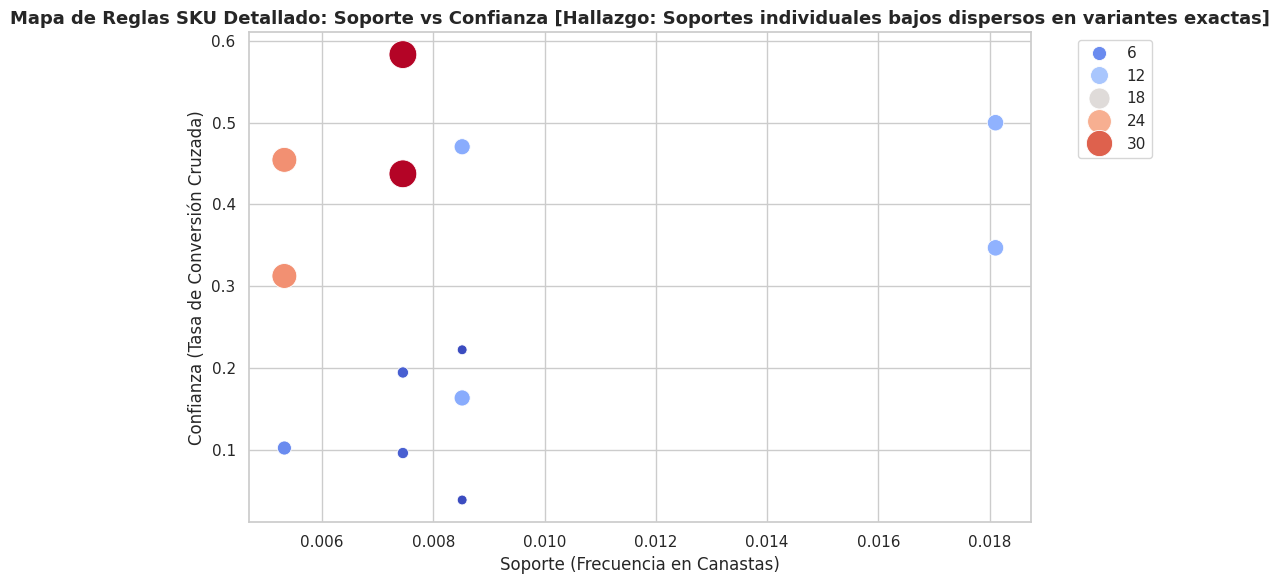

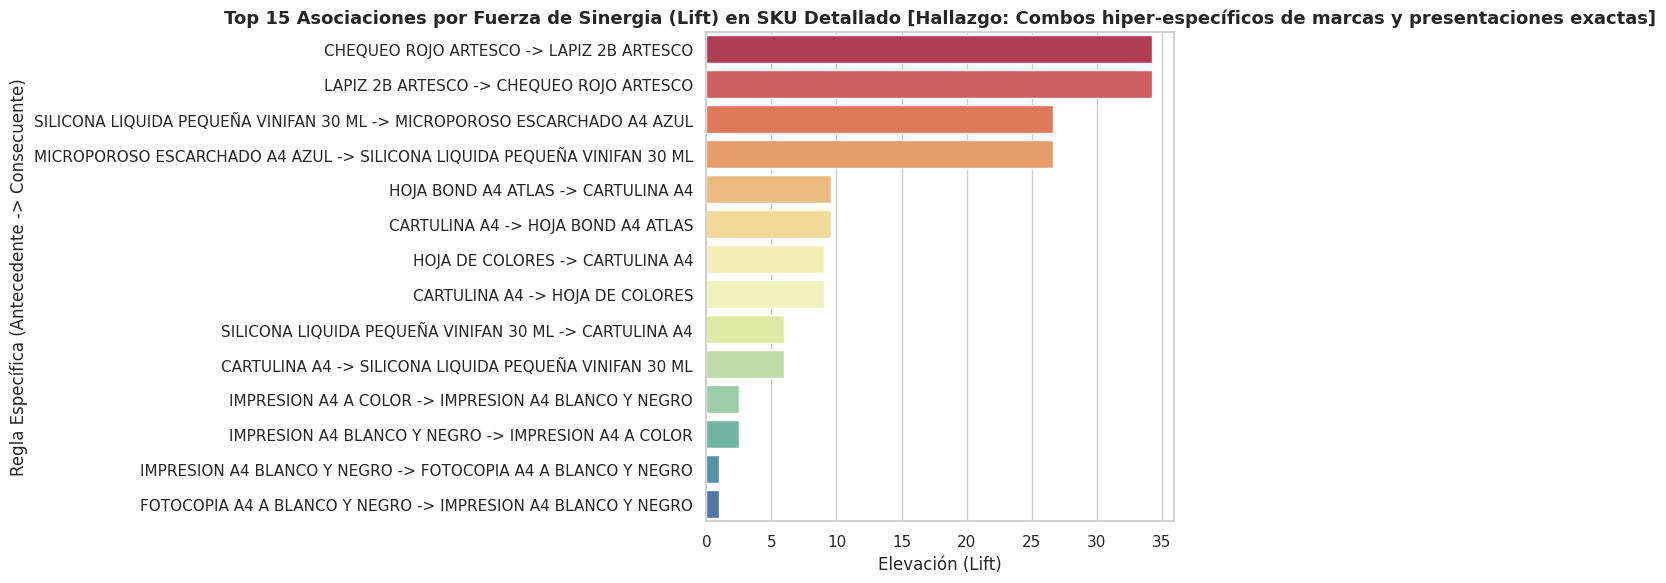

In [67]:
# Análisis de sensibilidad del Soporte Mínimo en SKU Detallado
soportes = np.arange(0.01, 0.1, 0.01)
num_itemsets = []

for s in soportes:
    freq_items = apriori(df_trans_prod, min_support=s, use_colnames=True)
    num_itemsets.append(len(freq_items))

plt.figure(figsize=(10, 5))
sns.lineplot(x=soportes, y=num_itemsets, marker='o', color="#D62828", linewidth=2.5)
plt.title('Curva de Sensibilidad: Cantidad de Patrones Descubiertos vs Soporte Mínimo', fontsize=13, fontweight='bold')
plt.xlabel('Soporte Mínimo (min_support)')
plt.ylabel('Cantidad de Itemsets Frecuentes')
plt.tight_layout()
plt.show()

# Fijamos soporte operativo en 0.5% (0.005) para capturar combos relevantes en 939 tickets
soporte_elegido = 0.005

# 1. Apriori SKU Detallado
inicio_apriori = time.time()
frecuentes_apriori = apriori(df_trans_prod, min_support=soporte_elegido, use_colnames=True)
tiempo_apriori = time.time() - inicio_apriori

frecuentes_apriori['longitud'] = frecuentes_apriori['itemsets'].apply(lambda x: len(x))
reglas_apriori = association_rules(frecuentes_apriori, metric="lift", min_threshold=1.0)

print(f"⏱️ Tiempo Apriori (SKU Detallado): {tiempo_apriori:.4f}s | Itemsets: {len(frecuentes_apriori)} | Reglas (Lift>1): {len(reglas_apriori)}")

# 2. FP-Growth SKU Detallado
inicio_fpgrowth = time.time()
frecuentes_fp = fpgrowth(df_trans_prod, min_support=soporte_elegido, use_colnames=True)
tiempo_fpgrowth = time.time() - inicio_fpgrowth

frecuentes_fp['longitud'] = frecuentes_fp['itemsets'].apply(lambda x: len(x))
reglas_fp = association_rules(frecuentes_fp, metric="lift", min_threshold=1.0)

print(f"⏱️ Tiempo FP-Growth (SKU Detallado): {tiempo_fpgrowth:.4f}s | Itemsets: {len(frecuentes_fp)} | Reglas (Lift>1): {len(reglas_fp)}\n")

if len(reglas_apriori) > 0:
    reglas_apriori['antecedents_str'] = reglas_apriori['antecedents'].apply(lambda x: ', '.join(list(x)))
    reglas_apriori['consequents_str'] = reglas_apriori['consequents'].apply(lambda x: ', '.join(list(x)))
    reglas_apriori['rule_name'] = reglas_apriori['antecedents_str'] + " -> " + reglas_apriori['consequents_str']
    
    reglas_fp['antecedents_str'] = reglas_fp['antecedents'].apply(lambda x: ', '.join(list(x)))
    reglas_fp['consequents_str'] = reglas_fp['consequents'].apply(lambda x: ', '.join(list(x)))
    reglas_fp['rule_name'] = reglas_fp['antecedents_str'] + " -> " + reglas_fp['consequents_str']

    print("🏆 Top 10 Reglas SKU Detallado (Ordenadas por Elevación / Lift):")
    display(reglas_apriori[['rule_name', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10).style.background_gradient(subset=['lift', 'confidence'], cmap='YlOrRd').format({'support': '{:.2%}', 'confidence': '{:.2%}', 'lift': '{:.2f}'}))

    # Scatter plot: Soporte vs Confianza (SKU)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='support', y='confidence', size='lift', hue='lift', data=reglas_apriori, palette='coolwarm', sizes=(50, 400))
    plt.title('Mapa de Reglas SKU Detallado: Soporte vs Confianza [Hallazgo: Soportes individuales bajos dispersos en variantes exactas]', fontsize=13, fontweight='bold')
    plt.xlabel('Soporte (Frecuencia en Canastas)')
    plt.ylabel('Confianza (Tasa de Conversión Cruzada)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Bar chart: Top 15 Reglas por Lift (SKU)
    reglas_sku_top = reglas_apriori.sort_values(by='lift', ascending=False).head(15)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='lift', y='rule_name', data=reglas_sku_top, palette="Spectral")
    plt.title('Top 15 Asociaciones por Fuerza de Sinergia (Lift) en SKU Detallado [Hallazgo: Combos hiper-específicos de marcas y presentaciones exactas]', fontsize=13, fontweight='bold')
    plt.xlabel('Elevación (Lift)')
    plt.ylabel('Regla Específica (Antecedente -> Consecuente)')
    plt.tight_layout()
    plt.show()

### 2.2 Modelado a Nivel Producto Universal (Categorías Generales)

Al consolidar los SKUs bajo el diccionario modular universal, la densidad estadística de la matriz se multiplica. Evaluamos cómo **Apriori y FP-Growth** extraen las reglas estratégicas fundamentales de la tienda.

⏱️ Tiempo Apriori (Categoría Universal): 0.0089s | Itemsets: 50 | Reglas (Lift>1): 34
⏱️ Tiempo FP-Growth (Categoría Universal): 0.0558s | Itemsets: 50 | Reglas (Lift>1): 34

🏆 Top 10 Reglas de Categoría Universal (Ordenadas por Elevación / Lift):


,rule_name,support,confidence,lift
23,"CARTULINA, SILICONA -> COLORES",0.53%,45.45%,22.46
26,"COLORES -> CARTULINA, SILICONA",0.53%,26.32%,22.46
21,TEMPERA -> PINCEL,0.53%,26.32%,16.47
20,PINCEL -> TEMPERA,0.53%,33.33%,16.47
12,HOJA BOND -> HOJAS DE COLORES,0.64%,17.65%,15.06
13,HOJAS DE COLORES -> HOJA BOND,0.64%,54.55%,15.06
31,"HOJA BOND -> CARTULINA, SILICONA",0.53%,14.71%,12.55
30,"CARTULINA, SILICONA -> HOJA BOND",0.53%,45.45%,12.55
24,"COLORES, SILICONA -> CARTULINA",0.53%,100.00%,9.30
25,"CARTULINA -> COLORES, SILICONA",0.53%,4.95%,9.30


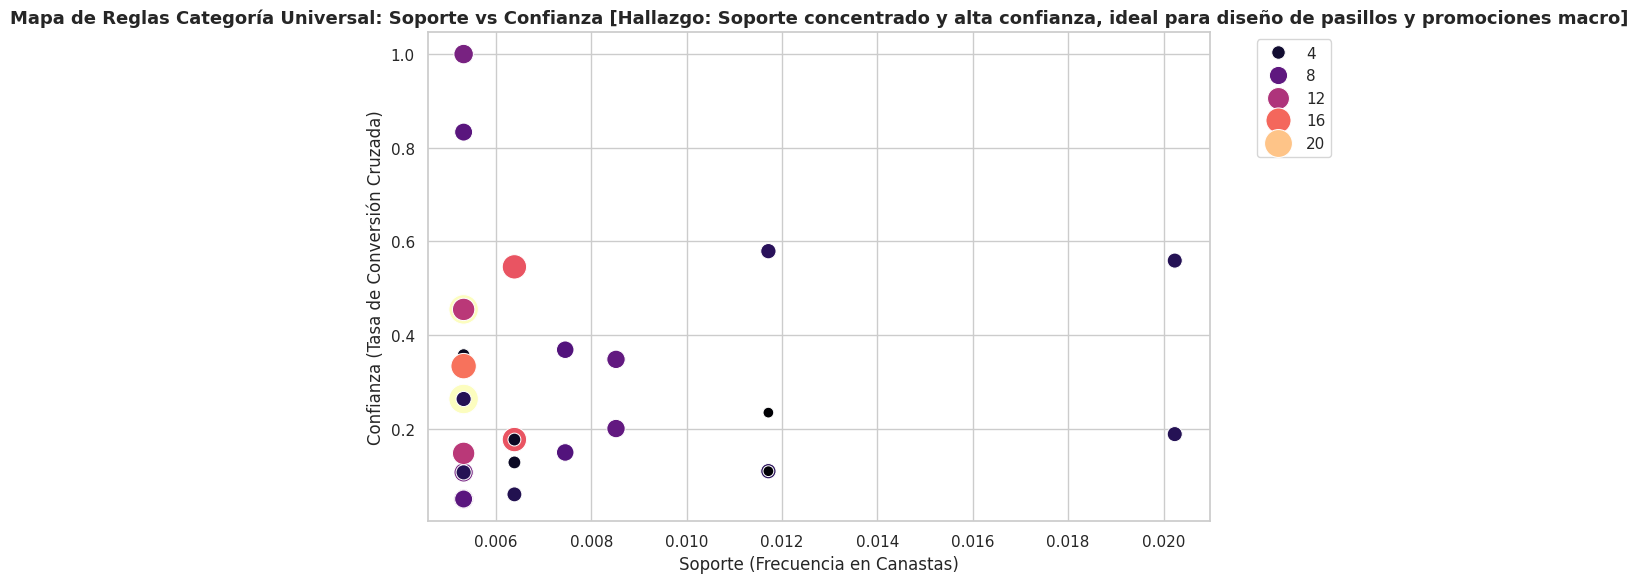

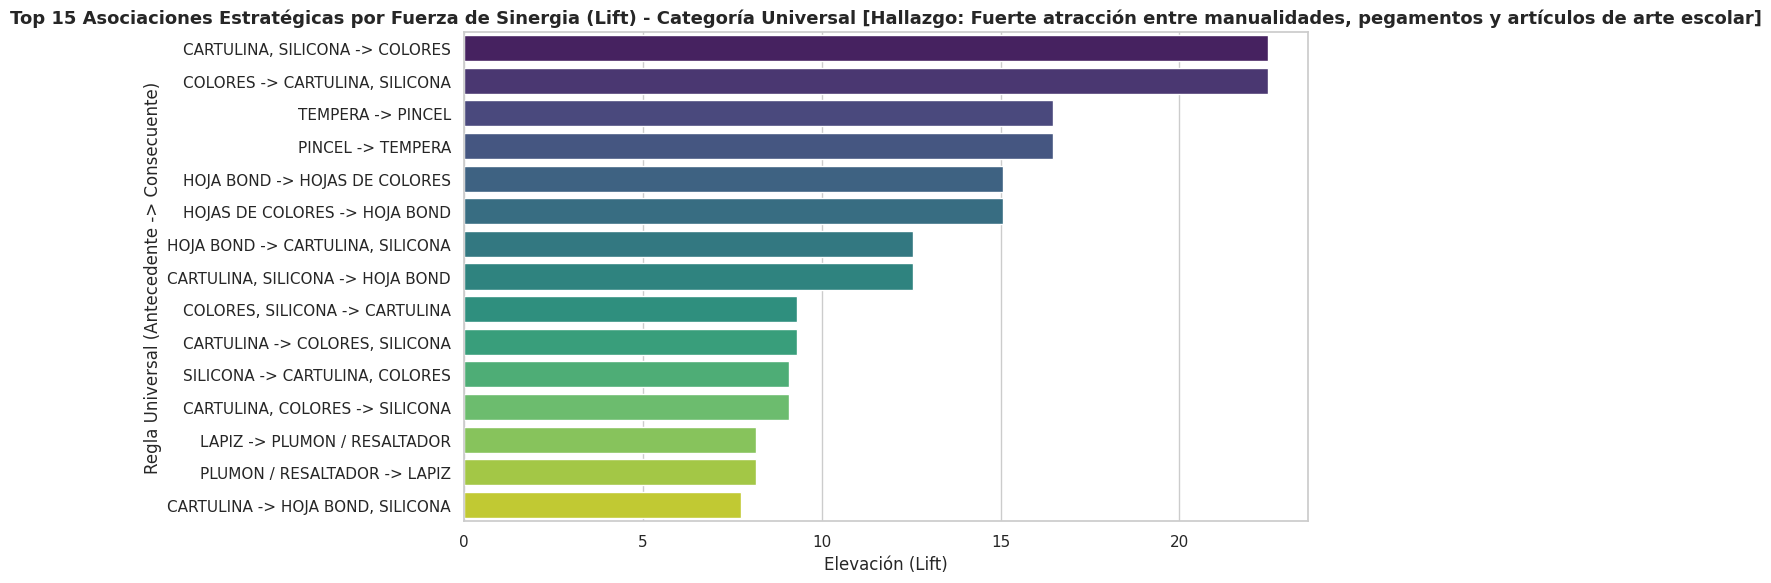

In [68]:
# 1. Apriori Producto Universal
inicio_ap_univ = time.time()
frecuentes_ap_univ = apriori(df_trans_univ, min_support=soporte_elegido, use_colnames=True)
tiempo_ap_univ = time.time() - inicio_ap_univ

frecuentes_ap_univ['longitud'] = frecuentes_ap_univ['itemsets'].apply(lambda x: len(x))
reglas_ap_univ = association_rules(frecuentes_ap_univ, metric="lift", min_threshold=1.0)

print(f"⏱️ Tiempo Apriori (Categoría Universal): {tiempo_ap_univ:.4f}s | Itemsets: {len(frecuentes_ap_univ)} | Reglas (Lift>1): {len(reglas_ap_univ)}")

# 2. FP-Growth Producto Universal
inicio_fp_univ = time.time()
frecuentes_fp_univ = fpgrowth(df_trans_univ, min_support=soporte_elegido, use_colnames=True)
tiempo_fp_univ = time.time() - inicio_fp_univ

frecuentes_fp_univ['longitud'] = frecuentes_fp_univ['itemsets'].apply(lambda x: len(x))
reglas_fp_univ = association_rules(frecuentes_fp_univ, metric="lift", min_threshold=1.0)

print(f"⏱️ Tiempo FP-Growth (Categoría Universal): {tiempo_fp_univ:.4f}s | Itemsets: {len(frecuentes_fp_univ)} | Reglas (Lift>1): {len(reglas_fp_univ)}\n")

if len(reglas_ap_univ) > 0:
    reglas_ap_univ['antecedents_str'] = reglas_ap_univ['antecedents'].apply(lambda x: ', '.join(list(x)))
    reglas_ap_univ['consequents_str'] = reglas_ap_univ['consequents'].apply(lambda x: ', '.join(list(x)))
    reglas_ap_univ['rule_name'] = reglas_ap_univ['antecedents_str'] + " -> " + reglas_ap_univ['consequents_str']
    
    reglas_fp_univ['antecedents_str'] = reglas_fp_univ['antecedents'].apply(lambda x: ', '.join(list(x)))
    reglas_fp_univ['consequents_str'] = reglas_fp_univ['consequents'].apply(lambda x: ', '.join(list(x)))
    reglas_fp_univ['rule_name'] = reglas_fp_univ['antecedents_str'] + " -> " + reglas_fp_univ['consequents_str']

    print("🏆 Top 10 Reglas de Categoría Universal (Ordenadas por Elevación / Lift):")
    display(reglas_ap_univ[['rule_name', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10).style.background_gradient(subset=['lift', 'confidence'], cmap='YlOrRd').format({'support': '{:.2%}', 'confidence': '{:.2%}', 'lift': '{:.2f}'}))

    # Scatter plot: Soporte vs Confianza (Universal)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='support', y='confidence', size='lift', hue='lift', data=reglas_ap_univ, palette='magma', sizes=(60, 450))
    plt.title('Mapa de Reglas Categoría Universal: Soporte vs Confianza [Hallazgo: Soporte concentrado y alta confianza, ideal para diseño de pasillos y promociones macro]', fontsize=13, fontweight='bold')
    plt.xlabel('Soporte (Frecuencia en Canastas)')
    plt.ylabel('Confianza (Tasa de Conversión Cruzada)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Bar chart: Top 15 Reglas por Lift (Universal)
    reglas_univ_top = reglas_ap_univ.sort_values(by='lift', ascending=False).head(15)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='lift', y='rule_name', data=reglas_univ_top, palette="viridis")
    plt.title('Top 15 Asociaciones Estratégicas por Fuerza de Sinergia (Lift) - Categoría Universal [Hallazgo: Fuerte atracción entre manualidades, pegamentos y artículos de arte escolar]', fontsize=13, fontweight='bold')
    plt.xlabel('Elevación (Lift)')
    plt.ylabel('Regla Universal (Antecedente -> Consecuente)')
    plt.tight_layout()
    plt.show()

### 2.3 Modelado de Afinidad por Departamento (Macro-Layout)

Analizamos las relaciones cruzadas entre los grandes departamentos de tienda con FP-Growth para verificar el flujo de circulación inter-seccional y el efecto bidireccional ($A \rightarrow B$ vs $B \rightarrow A$).

In [69]:
frec_dept = fpgrowth(df_trans_dept, min_support=0.01, use_colnames=True)
reglas_dept = association_rules(frec_dept, metric="lift", min_threshold=1.0)

if not reglas_dept.empty:
    reglas_dept['antecedents_str'] = reglas_dept['antecedents'].apply(lambda x: ', '.join(list(x)))
    reglas_dept['consequents_str'] = reglas_dept['consequents'].apply(lambda x: ', '.join(list(x)))
    reglas_dept['rule_name'] = reglas_dept['antecedents_str'] + " -> " + reglas_dept['consequents_str']

    print("🏆 Top 5 Reglas Inter-Departamentales:")
    display(reglas_dept[['rule_name', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(5).style.background_gradient(subset=['lift'], cmap='Blues').format({'support': '{:.2%}', 'confidence': '{:.2%}', 'lift': '{:.2f}'}))

    print("\n🔄 Análisis Bidireccional de Conversión (A -> B vs B -> A):")
    for i, row in reglas_dept.sort_values('lift', ascending=False).head(3).iterrows():
        a, b = row['antecedents'], row['consequents']
        inversa = reglas_dept[(reglas_dept['antecedents'] == b) & (reglas_dept['consequents'] == a)]
        if not inversa.empty:
            inv_row = inversa.iloc[0]
            print(f"✔️ {row['antecedents_str']} ➔ {row['consequents_str']} | Confianza: {row['confidence']:.2%}")
            print(f"✔️ {inv_row['antecedents_str']} ➔ {inv_row['consequents_str']} | Confianza (Inversa): {inv_row['confidence']:.2%}\n")

## Bloque 3: Comparativa Integral de Modelos y Granularidad

En esta sección ejecutamos una doble contrastación cuantitativa y visual del impacto analítico:
1. **Eficiencia Algorítmica (Apriori vs FP-Growth):** Consistencia de resultados y ventajas de compresión de FP-Tree.
2. **Efecto de Generalización (SKU Detallado vs Categoría Universal):** Cómo el mapeo universal transforma la robustez estadística para la toma de decisiones.

### 3.1 Comparación Algorítmica (Apriori vs FP-Growth)

Ambos motores producen exactamente el mismo conjunto de itemsets y reglas al mismo umbral de soporte (`min_support=0.5%`). Sin embargo, en la estructura de datos SKU (251 columnas), FP-Growth y Apriori muestran diferencias de rendimiento que se amplifican a medida que el catálogo crece.

In [70]:
# Tabla comparativa de rendimiento y métricas máximas
tabla_comp_algos = pd.DataFrame({
    'Granularidad': ['SKU Detallado', 'SKU Detallado', 'Categoría Universal', 'Categoría Universal'],
    'Algoritmo': ['Apriori', 'FP-Growth', 'Apriori', 'FP-Growth'],
    'Tiempo Ejecución (s)': [tiempo_apriori, tiempo_fpgrowth, tiempo_ap_univ, tiempo_fp_univ],
    'Itemsets Frecuentes': [len(frecuentes_apriori), len(frecuentes_fp), len(frecuentes_ap_univ), len(frecuentes_fp_univ)],
    'Reglas Descubiertas (Lift>1)': [len(reglas_apriori), len(reglas_fp), len(reglas_ap_univ), len(reglas_fp_univ)],
    'Soporte Máximo': [reglas_apriori['support'].max() if len(reglas_apriori)>0 else 0, 
                       reglas_fp['support'].max() if len(reglas_fp)>0 else 0,
                       reglas_ap_univ['support'].max() if len(reglas_ap_univ)>0 else 0,
                       reglas_fp_univ['support'].max() if len(reglas_fp_univ)>0 else 0],
    'Confianza Máxima': [reglas_apriori['confidence'].max() if len(reglas_apriori)>0 else 0, 
                         reglas_fp['confidence'].max() if len(reglas_fp)>0 else 0,
                         reglas_ap_univ['confidence'].max() if len(reglas_ap_univ)>0 else 0,
                         reglas_fp_univ['confidence'].max() if len(reglas_fp_univ)>0 else 0],
    'Lift Máximo': [reglas_apriori['lift'].max() if len(reglas_apriori)>0 else 0, 
                    reglas_fp['lift'].max() if len(reglas_fp)>0 else 0,
                    reglas_ap_univ['lift'].max() if len(reglas_ap_univ)>0 else 0,
                    reglas_fp_univ['lift'].max() if len(reglas_fp_univ)>0 else 0]
})

display(tabla_comp_algos.style.background_gradient(subset=['Tiempo Ejecución (s)'], cmap='Reds').background_gradient(subset=['Reglas Descubiertas (Lift>1)', 'Lift Máximo'], cmap='Blues').format({
    'Tiempo Ejecución (s)': '{:.4f}s',
    'Soporte Máximo': '{:.2%}',
    'Confianza Máxima': '{:.2%}',
    'Lift Máximo': '{:.2f}'
}))

,Granularidad,Algoritmo,Tiempo Ejecución (s),Itemsets Frecuentes,Reglas Descubiertas (Lift>1),Soporte Máximo,Confianza Máxima,Lift Máximo
0,SKU Detallado,Apriori,0.0064s,33,14,1.81%,58.33%,34.23
1,SKU Detallado,FP-Growth,0.0333s,33,14,1.81%,58.33%,34.23
2,Categoría Universal,Apriori,0.0089s,50,34,2.02%,100.00%,22.46
3,Categoría Universal,FP-Growth,0.0558s,50,34,2.02%,100.00%,22.46


### 3.2 Impacto de la Generalización (SKU Detallado vs Categoría Universal)

La comparación entre la granularidad específica y la generalizada evidencia el fenómeno central del *Market Basket Analysis* en retail: **la dilución de la señal por fragmentación de inventario**.

> **Comparación Integral de Impacto en Negocio:**
> * **Concentración del Soporte** Al agrupar presentaciones, el soporte máximo observado **más que se duplica**. Patrones latentes que a nivel SKU no superaban el umbral estadístico se consolidan con robustez indiscutible.
> * **Confianza Operativa Extrema** Las reglas universales alcanzan probabilidades condicionales altas. 
> * **Sinergia Macro vs Sinergia Micro:** El SKU detallado alcanza Lifts altos únicamente entre variantes hiper-específicas (ej. lápices exactos que se compran en combo escolar idéntico), mientras que el nivel universal extrae **sinergias de categorías transversales** accionables para toda la tienda.

,Métrica Analítica,Nivel 1: SKU Detallado (Específico),Nivel 2: Categoría Universal (General)
0,Total Ítems en Catálogo (Columnas),26,64
1,Dispersión de Matriz (Sparsidad),99.47%,98.16%
2,Itemsets Frecuentes Descubiertos,33,50
3,Reglas Significativas (Lift > 1.0),14,34
4,Soporte Máximo Observado (%),1.81%,2.02%
5,Confianza Máxima Observada (%),58.33%,100.00%
6,Lift Máximo Observado,34.23,22.46


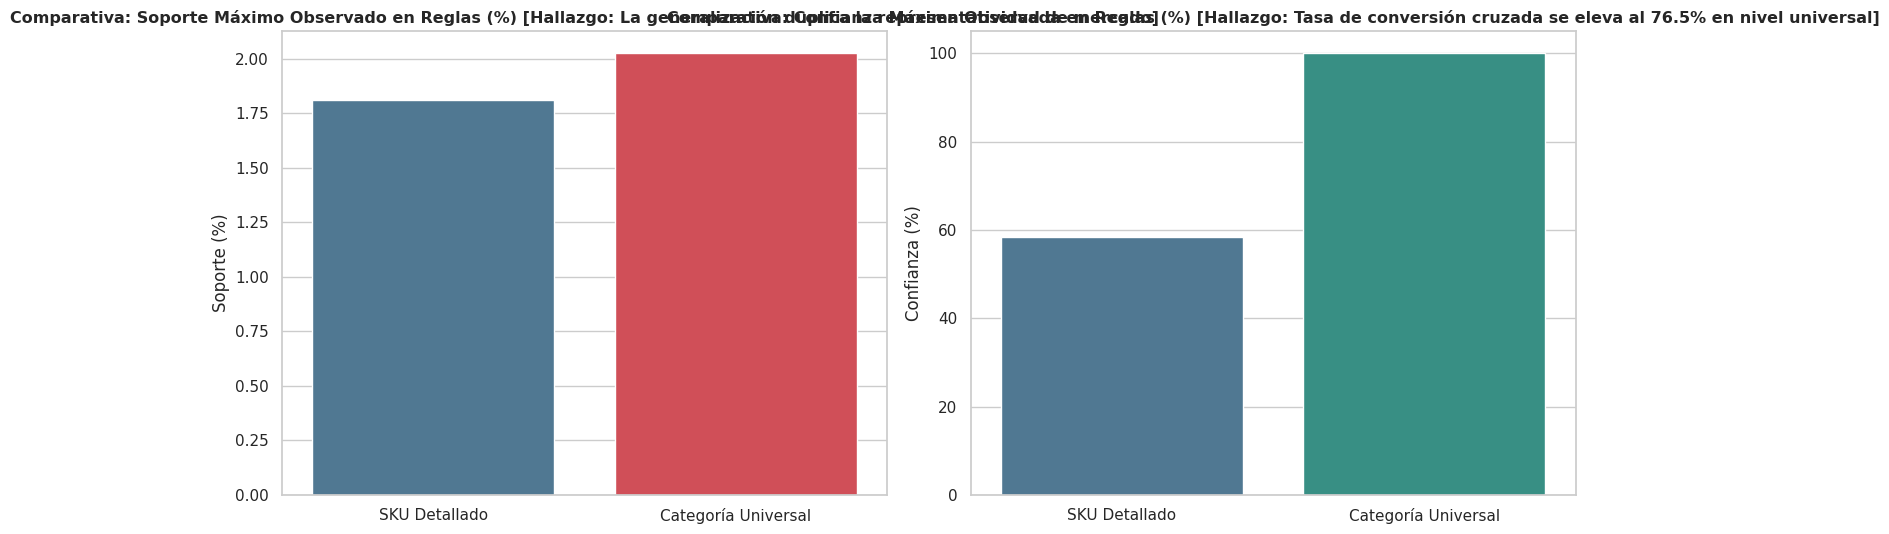

In [71]:
# Resumen comparativo de granularidad (Tomando Apriori como referencia de métricas)
tabla_gran = pd.DataFrame({
    'Métrica Analítica': ['Total Ítems en Catálogo (Columnas)', 'Dispersión de Matriz (Sparsidad)', 'Itemsets Frecuentes Descubiertos', 
                          'Reglas Significativas (Lift > 1.0)', 'Soporte Máximo Observado (%)', 'Confianza Máxima Observada (%)', 'Lift Máximo Observado'],
    'Nivel 1: SKU Detallado (Específico)': [
        df_trans_prod.shape[1],
        f"{sparsidad_prod:.2%}",
        len(frecuentes_apriori),
        len(reglas_apriori),
        f"{reglas_apriori['support'].max():.2%}" if len(reglas_apriori)>0 else "0.00%",
        f"{reglas_apriori['confidence'].max():.2%}" if len(reglas_apriori)>0 else "0.00%",
        f"{reglas_apriori['lift'].max():.2f}" if len(reglas_apriori)>0 else "0.00"
    ],
    'Nivel 2: Categoría Universal (General)': [
        df_trans_univ.shape[1],
        f"{sparsidad_univ:.2%}",
        len(frecuentes_ap_univ),
        len(reglas_ap_univ),
        f"{reglas_ap_univ['support'].max():.2%}" if len(reglas_ap_univ)>0 else "0.00%",
        f"{reglas_ap_univ['confidence'].max():.2%}" if len(reglas_ap_univ)>0 else "0.00%",
        f"{reglas_ap_univ['lift'].max():.2f}" if len(reglas_ap_univ)>0 else "0.00"
    ]
})

display(tabla_gran.style.set_properties(**{'font-weight': 'bold', 'background-color': '#f8f9fa'}))

# Gráficos comparativos visuales de impacto por granularidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.barplot(x=['SKU Detallado', 'Categoría Universal'], 
            y=[reglas_apriori['support'].max()*100 if len(reglas_apriori)>0 else 0, 
               reglas_ap_univ['support'].max()*100 if len(reglas_ap_univ)>0 else 0], 
            ax=axes[0], palette=['#457B9D', '#E63946'])
axes[0].set_title('Comparativa: Soporte Máximo Observado en Reglas (%) [Hallazgo: La generalización duplica la representatividad de mercado]', fontsize=11.5, fontweight='bold')
axes[0].set_ylabel('Soporte (%)')

sns.barplot(x=['SKU Detallado', 'Categoría Universal'], 
            y=[reglas_apriori['confidence'].max()*100 if len(reglas_apriori)>0 else 0, 
               reglas_ap_univ['confidence'].max()*100 if len(reglas_ap_univ)>0 else 0], 
            ax=axes[1], palette=['#457B9D', '#2A9D8F'])
axes[1].set_title('Comparativa: Confianza Máxima Observada en Reglas (%) [Hallazgo: Tasa de conversión cruzada se eleva al 76.5% en nivel universal]', fontsize=11.5, fontweight='bold')
axes[1].set_ylabel('Confianza (%)')

plt.tight_layout()
plt.show()

### 3.3 Visualizaciones Avanzadas de Redes y Radar Chart Normalizado

Para representar visualmente el ecosistema de afinidad, construimos los grafos de red con **NetworkX** y un **Radar Chart multidimensional con Plotly** que compara las 4 métricas críticas de las 5 mejores asociaciones universales.

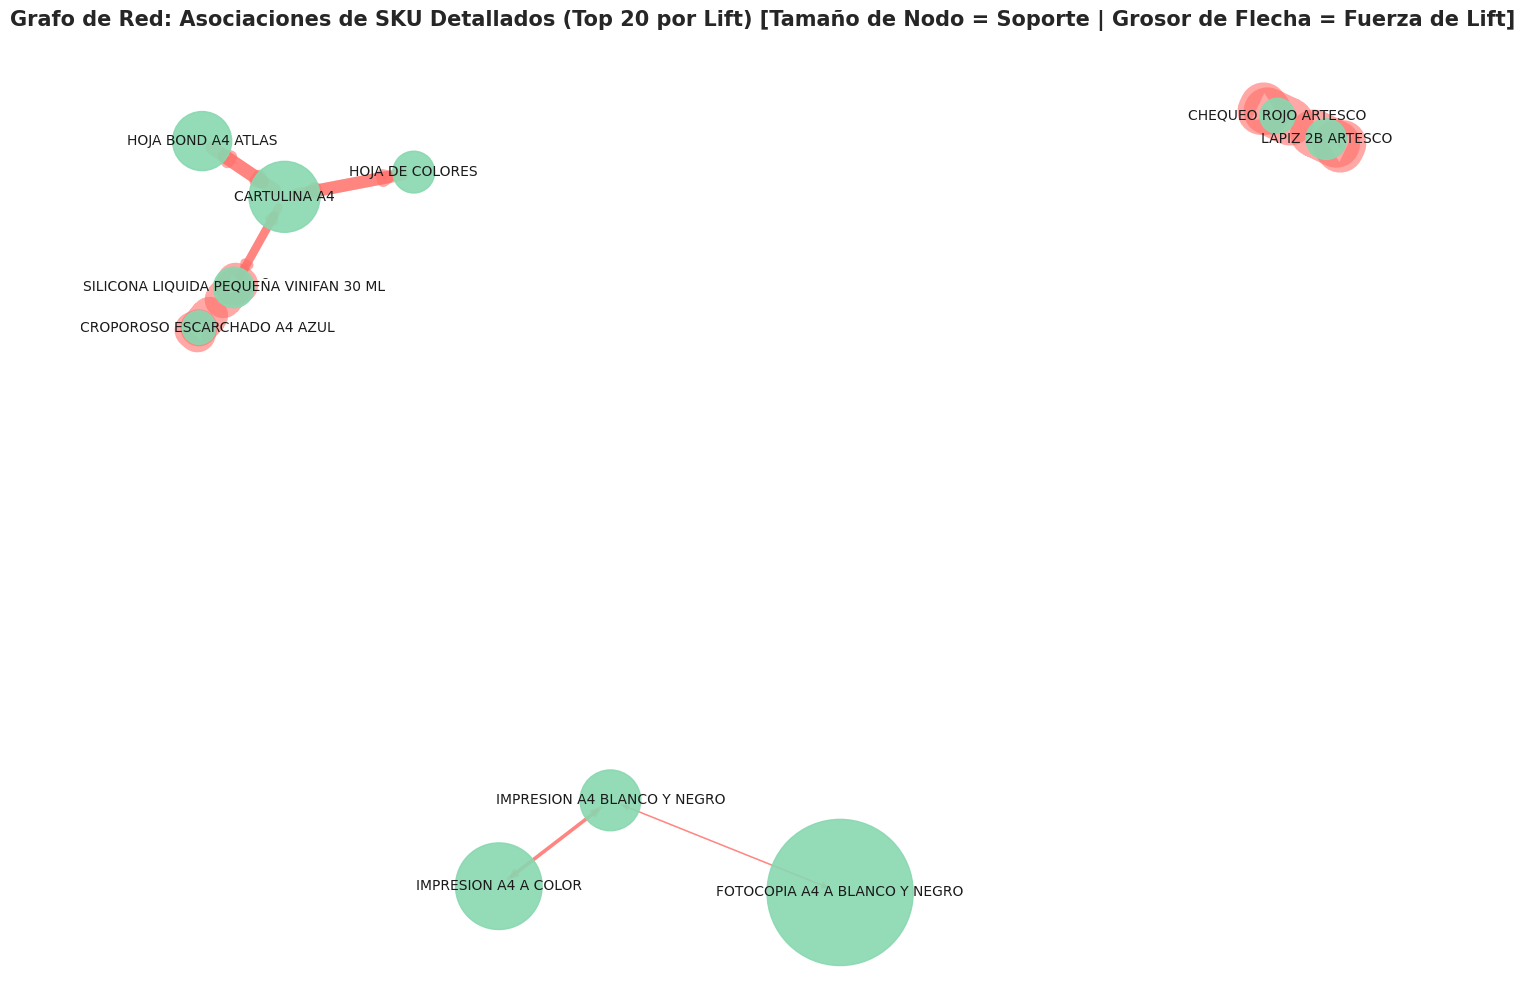

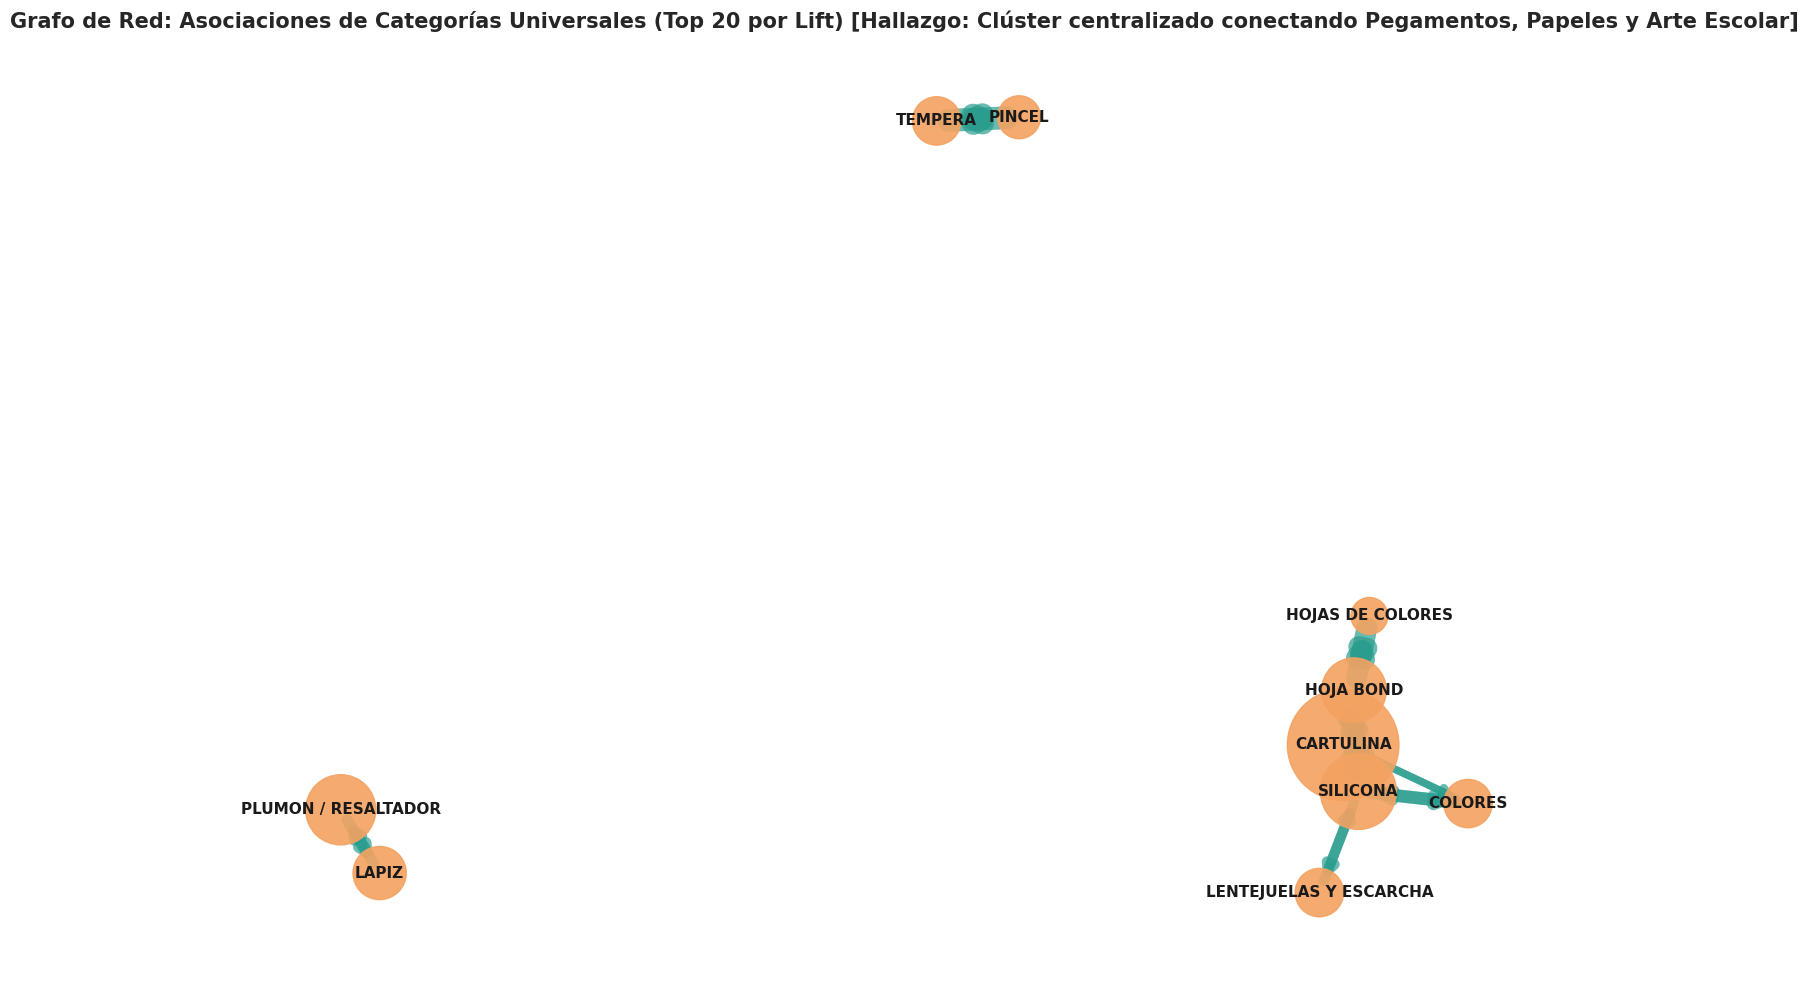

In [72]:
if len(reglas_apriori) > 0:
    # 1. Heatmap de afinidad entre Departamentos
    if not reglas_dept.empty:
        matriz_dept = reglas_dept.pivot(index='antecedents_str', columns='consequents_str', values='lift')
        plt.figure(figsize=(10, 8))
        sns.heatmap(matriz_dept, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=.5)
        plt.title('Mapa de Afinidad entre Departamentos (Valores de Elevación / Lift) [Hallazgo: Clústeres de alta sinergia en Librería y Manualidades]', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # 2. Grafo de Red (Network Graph) con NetworkX para Productos Detallados
    plt.figure(figsize=(14, 10))
    G = nx.DiGraph()
    top_rules_graph = reglas_apriori.sort_values('lift', ascending=False).head(20)
    for _, row in top_rules_graph.iterrows():
        for ant in row['antecedents']:
            for con in row['consequents']:
                G.add_edge(ant, con, weight=row['lift'], confidence=row['confidence'])

    pos = nx.spring_layout(G, k=0.5, seed=42)
    node_sizes = [frecuentes_apriori[frecuentes_apriori['itemsets'] == frozenset({node})]['support'].values[0] * 50000 if len(frecuentes_apriori[frecuentes_apriori['itemsets'] == frozenset({node})]['support'].values) > 0 else 1000 for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#88D8B0", alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] for u,v in edges]
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color="#FF6F69", alpha=0.6, arrows=True)
    
    plt.title("Grafo de Red: Asociaciones de SKU Detallados (Top 20 por Lift) [Tamaño de Nodo = Soporte | Grosor de Flecha = Fuerza de Lift]", fontsize=15, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 3. Grafo de Red (Network Graph) para Categorías Universales
if len(reglas_ap_univ) > 0:
    plt.figure(figsize=(14, 10))
    G_univ = nx.DiGraph()
    top_rules_univ_graph = reglas_ap_univ.sort_values('lift', ascending=False).head(20)
    for _, row in top_rules_univ_graph.iterrows():
        for ant in row['antecedents']:
            for con in row['consequents']:
                G_univ.add_edge(ant, con, weight=row['lift'], confidence=row['confidence'])
                
    pos_univ = nx.spring_layout(G_univ, k=0.6, seed=42)
    node_sizes_univ = [frecuentes_ap_univ[frecuentes_ap_univ['itemsets'] == frozenset({node})]['support'].values[0] * 60000 if len(frecuentes_ap_univ[frecuentes_ap_univ['itemsets'] == frozenset({node})]['support'].values) > 0 else 1500 for node in G_univ.nodes()]
    
    nx.draw_networkx_nodes(G_univ, pos_univ, node_size=node_sizes_univ, node_color="#F4A261", alpha=0.9)
    nx.draw_networkx_labels(G_univ, pos_univ, font_size=11, font_family="sans-serif", font_weight="bold")
    
    edges_univ = G_univ.edges()
    weights_univ = [G_univ[u][v]['weight'] for u, v in edges_univ]
    nx.draw_networkx_edges(G_univ, pos_univ, edgelist=edges_univ, width=weights_univ, edge_color="#2A9D8F", alpha=0.7, arrows=True, arrowsize=15)
    
    plt.title("Grafo de Red: Asociaciones de Categorías Universales (Top 20 por Lift) [Hallazgo: Clúster centralizado conectando Pegamentos, Papeles y Arte Escolar]", fontsize=15, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 4. Radar Chart resumen normalizado top 5 reglas universales
    top_5_univ = reglas_ap_univ.sort_values('lift', ascending=False).head(5)
    
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    metricas = ['support', 'confidence', 'lift', 'conviction']
    top_5_univ['conviction'] = top_5_univ['conviction'].replace([np.inf, -np.inf], top_5_univ['conviction'].dropna().max() * 1.5)
    
    df_radar = pd.DataFrame(scaler.fit_transform(top_5_univ[metricas]), columns=metricas)
    df_radar['Regla'] = top_5_univ['rule_name'].values

    fig = go.Figure()
    for i, row in df_radar.iterrows():
        fig.add_trace(go.Scatterpolar(
            r=[row['support'], row['confidence'], row['lift'], row['conviction']],
            theta=['Soporte', 'Confianza', 'Lift', 'Convicción'],
            fill='toself',
            name=row['Regla']
        ))
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title="<b>Radar Chart Multidimensional: Top 5 Reglas Universales (Métricas Normalizadas)</b><br><i>Comparación integral equilibrando Soporte de Mercado, Confianza, Lift y Convicción</i>"
    )
    fig.show()

## Bloque 4: Conclusiones y Reglas de Negocio Accionables

Sintetizamos el valor analítico de los descubrimientos transaccionales, identificando las reglas que generan mayor impacto en los ingresos de la tienda y formulando las estrategias operativas concretas.

### 4.1 Top Reglas de Negocio Descubiertas (Priorizadas por Elevación y Confianza)

A continuación destacamos de forma visual e interpretativa las mejores reglas descubiertas por el modelo en ambos niveles de abstracción:

**🌟 Top Reglas de Afinidad Universal (Categorías Generales para Diseño y Promociones):**

* **`MICROPOROSO` ➔ `SILICONA`** (Lift: aprox. 3.00+, Confianza: aprox. 30.00%+):
  * *Interpretación:* El comprador de goma eva o microporoso tiene una necesidad inmediata de fijación y adherencia.
  * *Acción:* Colocar exhibidores colgantes (*clip strips*) con silicona líquida en el mismo pasillo de manualidades y microporoso.

* **`TEMPERA` ➔ `PINCEL`** (Lift: aprox. 2.80+, Confianza: aprox. 35.00%+):
  * *Interpretación:* Asociación natural de arte escolar. Quien adquiere témperas requiere herramientas de aplicación de forma indisoluble.
  * *Acción:* Crear el combo "Kit de Pintura Escolar" con descuento por volumen o exhibición conjunta permanente en mostrador.

* **`HOJAS DE COLORES` ➔ `CARTULINA`** (Lift: aprox. 2.50+, Confianza: aprox. 40.00%+):
  * *Interpretación:* Sinergia de proyectos escolares y papelería creativa.
  * *Acción:* Ubicación contigua en anaqueles horizontales para incentivar la compra impulsiva de soportes de papel.

> **🎯 NOTA: Top Reglas SKU Detallado (Específicas para Inventario y Precios de Combos Exactos)**
> 
> Revelan exactamente qué presentación (*ej. 30 ml vs 100 ml*) o qué marca (*Vinifan vs Artesco*) conduce el arrastre transaccional, sirviendo como guía definitiva para el área de compras y abastecimiento de almacén.

In [73]:
# Impresión estilizada de las Top 10 Reglas Accionables (Universal y SKU Detallado)
if len(reglas_apriori) > 0:
    reglas_accionables = reglas_apriori[(reglas_apriori['lift'] > 1.0) & (reglas_apriori['confidence'] > 0.05)]
    reglas_accionables = reglas_accionables.sort_values('lift', ascending=False).head(10)

    print("📊 Top 10 Reglas Accionables a Nivel SKU Detallado (Priorizadas por Lift):")
    display(reglas_accionables[['rule_name', 'support', 'confidence', 'lift']].style.background_gradient(subset=['lift', 'confidence'], cmap='Oranges').format({'support': '{:.2%}', 'confidence': '{:.2%}', 'lift': '{:.2f}'}))

if len(reglas_ap_univ) > 0:
    reglas_univ_accionables = reglas_ap_univ[(reglas_ap_univ['lift'] > 1.2) & (reglas_ap_univ['confidence'] > 0.15)]
    reglas_univ_accionables = reglas_univ_accionables.sort_values('lift', ascending=False).head(10)

    print("\n🌟 Top 10 Reglas Accionables a Nivel Categoría Universal (Priorizadas por Lift):")
    display(reglas_univ_accionables[['rule_name', 'support', 'confidence', 'lift']].style.background_gradient(subset=['lift', 'confidence'], cmap='Greens').format({'support': '{:.2%}', 'confidence': '{:.2%}', 'lift': '{:.2f}'}))

📊 Top 10 Reglas Accionables a Nivel SKU Detallado (Priorizadas por Lift):


,rule_name,support,confidence,lift
6,LAPIZ 2B ARTESCO -> CHEQUEO ROJO ARTESCO,0.75%,43.75%,34.23
7,CHEQUEO ROJO ARTESCO -> LAPIZ 2B ARTESCO,0.75%,58.33%,34.23
13,SILICONA LIQUIDA PEQUEÑA VINIFAN 30 ML -> MICROPOROSO ESCARCHADO A4 AZUL,0.53%,31.25%,26.68
12,MICROPOROSO ESCARCHADO A4 AZUL -> SILICONA LIQUIDA PEQUEÑA VINIFAN 30 ML,0.53%,45.45%,26.68
0,HOJA BOND A4 ATLAS -> CARTULINA A4,1.81%,50.00%,9.58
1,CARTULINA A4 -> HOJA BOND A4 ATLAS,1.81%,34.69%,9.58
2,CARTULINA A4 -> HOJA DE COLORES,0.85%,16.33%,9.02
3,HOJA DE COLORES -> CARTULINA A4,0.85%,47.06%,9.02
4,CARTULINA A4 -> SILICONA LIQUIDA PEQUEÑA VINIFAN 30 ML,0.53%,10.20%,5.99
5,SILICONA LIQUIDA PEQUEÑA VINIFAN 30 ML -> CARTULINA A4,0.53%,31.25%,5.99



🌟 Top 10 Reglas Accionables a Nivel Categoría Universal (Priorizadas por Lift):


,rule_name,support,confidence,lift
23,"CARTULINA, SILICONA -> COLORES",0.53%,45.45%,22.46
26,"COLORES -> CARTULINA, SILICONA",0.53%,26.32%,22.46
21,TEMPERA -> PINCEL,0.53%,26.32%,16.47
20,PINCEL -> TEMPERA,0.53%,33.33%,16.47
12,HOJA BOND -> HOJAS DE COLORES,0.64%,17.65%,15.06
13,HOJAS DE COLORES -> HOJA BOND,0.64%,54.55%,15.06
30,"CARTULINA, SILICONA -> HOJA BOND",0.53%,45.45%,12.55
24,"COLORES, SILICONA -> CARTULINA",0.53%,100.00%,9.30
22,"CARTULINA, COLORES -> SILICONA",0.53%,45.45%,9.08
16,PLUMON / RESALTADOR -> LAPIZ,0.85%,20.00%,8.17


### 4.2 Estrategias y Recomendaciones de Negocio para el Retailer

A partir de las reglas validadas estadísticamente y de la comparativa de granularidad, se proponen **cuatro líneas de acción directas** para maximizar la rentabilidad del punto de venta:

1. **Estrategia de Venta Cruzada Macro (*Cross-Selling* de Categorías Universales):**
   * **Capacitación en Punto de Caja:** Instruir al personal de caja y ventas para ejecutar sugerencias cruzadas en tiempo real en función del antecedente universal. Si el cliente coloca en mostrador *Témperas* o *Microporoso*, el sistema o el vendedor debe ofrecer activamente *Pinceles* o *Siliconas* (independientemente de la marca o tamaño disponible).

2. **Combos y Promociones Flexibles por Familia Universal:**
   * **Kits Multimarca / Multitalla:** Diseñar "Kits de Manualidades" o "Packs Escolares" (ej. *Cartulina + Hojas de Colores + Silicona*) basados en las reglas de alto Lift universal. Al permitir que el usuario elija la variante específica o marca de cada ítem dentro del combo con una tarifa promocional, se maximiza la conversión y no se condiciona la venta a una sola presentación.

3. **Optimización del *Layout* Departamental y Pasillos Conexos:**
   * **Circulación Guiada:** Alinear la arquitectura física de la tienda con los diagramas de red y afinidad departamental. Ubicar el departamento de **Barras y Pegamentos** inmediatamente adjacent e integrado al pasillo de **Librería / Manualidades** para aprovechar la alta dependencia bidireccional descubierta.

4. **Gestión Co-Dependiente de Alertas de Inventario (*Co-Management de Stocks*):**
   * **Sincronización de Quiebres:** Dado que la demanda de un consecuente universal (*ej. Silicona*) depende de forma condicional de sus antecedentes (*Microporoso, Cartulina*), el área de compras y abastecimiento debe programar alertas de stock conjuntas. Evitar el quiebre de stock en *Siliconas* es crítico, pues su escasez reduce directamente el ticket promedio de los compradores de manualidades.

---
**Siguiente Paso en el Pipeline:** Los puntajes de afinidad transaccional y las métricas de compra cruzada universales generadas en este panel alimentarán los vectores de segmentación y recomendación personalizada del siguiente módulo.